# TP Problème ouvert - Prédiction de maladies
> Célian Chausson & Nils Saadi - INFRES 17

In [916]:
# Imports nécessaires
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import warnings
warnings.filterwarnings('ignore')

# Configuration des plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Chargement et exploration des données

In [917]:
# Charger les données
file_path = 'SynMedTab-800.csv'
df = pd.read_csv(file_path)

# Afficher les 5 premières lignes
print("\n--- Aperçu des 5 premières lignes du dataset ---")
print(df.head())

print(f"\nTaille du dataset : {df.shape[0]} lignes, {df.shape[1]} colonnes")


--- Aperçu des 5 premières lignes du dataset ---
   patient_id   age  blood_pressure_mmhg  cholesterol_mgdl  glucose_mgdl  \
0           1  68.7                125.6             193.9           NaN   
1           2  64.3                132.5             173.4          75.2   
2           3  51.1                118.3             213.3          86.4   
3           4   NaN                146.7             193.7          82.9   
4           5  47.5                144.3             182.6         182.6   

    bmi smoking_status physical_activity family_history diet_quality disease  
0  29.5          Never          Moderate             No    Excellent      No  
1  24.5          Never          Moderate             No         Fair      No  
2  26.2         Former              High            NaN         Good      No  
3  27.8          Never               NaN             No          NaN      No  
4  31.6          Never               Low            Yes         Poor     Yes  

Taille du dataset 

In [918]:
print("--- Types de données ---")
print(f"{df.dtypes}")

print("\n--- Valeurs manquantes ---")
print(f"{df.isnull().sum()}")

--- Types de données ---
patient_id               int64
age                    float64
blood_pressure_mmhg    float64
cholesterol_mgdl       float64
glucose_mgdl           float64
bmi                    float64
smoking_status             str
physical_activity          str
family_history             str
diet_quality               str
disease                    str
dtype: object

--- Valeurs manquantes ---
patient_id              0
age                    84
blood_pressure_mmhg    70
cholesterol_mgdl       79
glucose_mgdl           96
bmi                    67
smoking_status         69
physical_activity      90
family_history         83
diet_quality           88
disease                 0
dtype: int64


In [919]:
print("--- Informations générales sur le dataset ---")
df.info()

print("\n--- Statistiques descriptives des colonnes numériques ---")
df.describe()

--- Informations générales sur le dataset ---
<class 'pandas.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   patient_id           800 non-null    int64  
 1   age                  716 non-null    float64
 2   blood_pressure_mmhg  730 non-null    float64
 3   cholesterol_mgdl     721 non-null    float64
 4   glucose_mgdl         704 non-null    float64
 5   bmi                  733 non-null    float64
 6   smoking_status       731 non-null    str    
 7   physical_activity    710 non-null    str    
 8   family_history       717 non-null    str    
 9   diet_quality         712 non-null    str    
 10  disease              800 non-null    str    
dtypes: float64(5), int64(1), str(5)
memory usage: 68.9 KB

--- Statistiques descriptives des colonnes numériques ---


,patient_id,age,blood_pressure_mmhg,cholesterol_mgdl,glucose_mgdl,bmi
count,800.0000,716.000000,730.000000,721.000000,704.000000,733.000000
mean,400.5000,51.353911,126.327397,209.344105,107.010085,26.539291
std,231.0844,13.256483,19.297168,37.638613,29.352447,4.697594
min,1.0000,18.000000,78.800000,105.400000,50.000000,15.000000
25%,200.7500,43.075000,113.600000,185.900000,88.300000,23.300000
50%,400.5000,51.600000,124.800000,206.000000,101.250000,26.100000
75%,600.2500,60.050000,137.850000,232.000000,119.850000,29.600000
max,800.0000,89.700000,199.400000,335.800000,243.100000,43.300000


## 2. Analyse exploratoire des données (EDA)

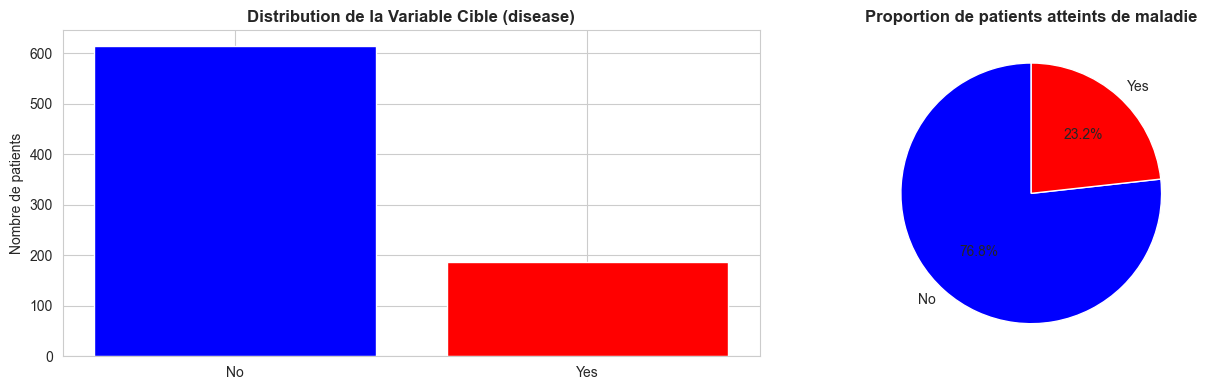

Distribution de la cible :
disease
No     614
Yes    186
Name: count, dtype: int64

Pourcentages :
disease
No     76.75
Yes    23.25
Name: proportion, dtype: float64


In [920]:
# Distribution de la variable cible
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Comptage
disease_counts = df['disease'].value_counts()
axes[0].bar(disease_counts.index, disease_counts.values, color=['Blue', 'Red'])
axes[0].set_title('Distribution de la Variable Cible (disease)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Nombre de patients')

# Pourcentage
disease_pct = df['disease'].value_counts(normalize=True) * 100
axes[1].pie(disease_pct.values, labels=disease_pct.index, autopct='%1.1f%%', 
            colors=['Blue', 'Red'], startangle=90)
axes[1].set_title('Proportion de patients atteints de maladie', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"Distribution de la cible :\n{disease_counts}")
print(f"\nPourcentages :\n{disease_pct}")

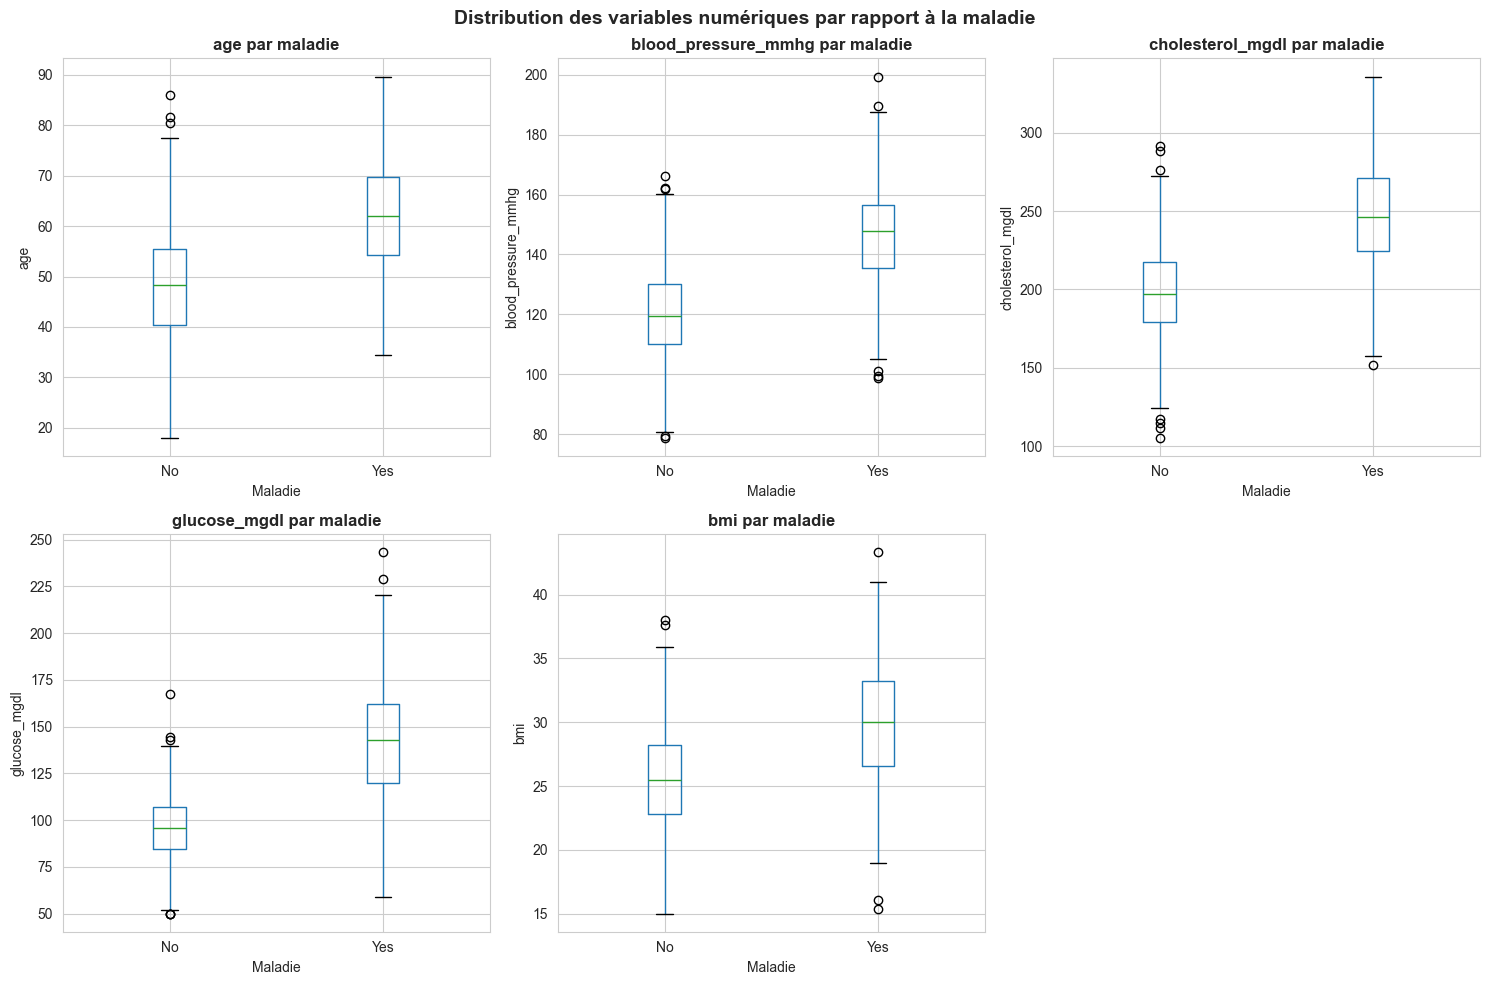

In [921]:
# Variables numériques par rapport à la cible
numeric_cols = ['age', 'blood_pressure_mmhg', 'cholesterol_mgdl', 'glucose_mgdl', 'bmi']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    df.boxplot(column=col, by='disease', ax=axes[i])
    axes[i].set_title(f'{col} par maladie', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Maladie')
    axes[i].set_ylabel(col)

# Masquer le dernier subplot vide
axes[-1].axis('off')
plt.suptitle('Distribution des variables numériques par rapport à la maladie', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

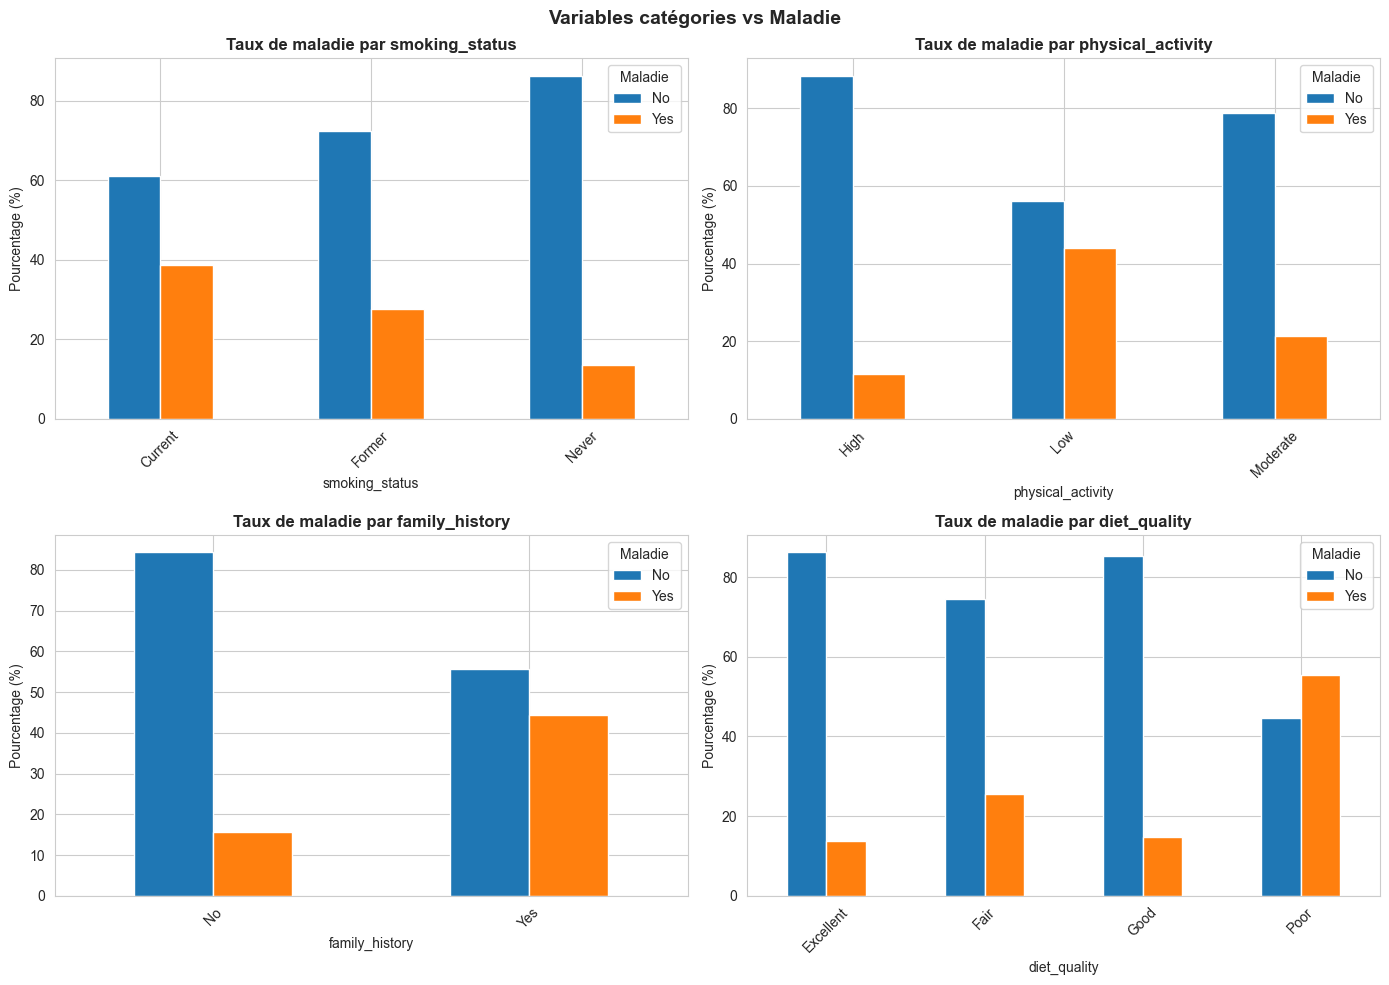

In [922]:
# Variables catégories
categorical_cols = ['smoking_status', 'physical_activity', 'family_history', 'diet_quality']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    cross_tab = pd.crosstab(df[col], df['disease'], normalize='index') * 100
    cross_tab.plot(kind='bar', ax=axes[i])
    axes[i].set_title(f'Taux de maladie par {col}', fontweight='bold')
    axes[i].set_ylabel('Pourcentage (%)')
    axes[i].set_xlabel(col)
    axes[i].legend(title='Maladie')
    axes[i].tick_params(axis='x', rotation=45)

plt.suptitle('Variables catégories vs Maladie', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Prétraitement des données

In [923]:
# Copier le dataframe pour le prétraitement
df_processed = df.copy()

# Traiter les valeurs manquantes
print("Valeurs manquantes avant imputation:")
print(df_processed.isnull().sum())

# Imputation des valeurs manquantes
numeric_imputer = SimpleImputer(strategy='median')
df_processed[numeric_cols] = numeric_imputer.fit_transform(df_processed[numeric_cols])

categorical_imputer = SimpleImputer(strategy='most_frequent')
df_processed[categorical_cols] = categorical_imputer.fit_transform(df_processed[categorical_cols])

print("\nValeurs manquantes après imputation :")
print(df_processed.isnull().sum())

Valeurs manquantes avant imputation:
patient_id              0
age                    84
blood_pressure_mmhg    70
cholesterol_mgdl       79
glucose_mgdl           96
bmi                    67
smoking_status         69
physical_activity      90
family_history         83
diet_quality           88
disease                 0
dtype: int64

Valeurs manquantes après imputation :
patient_id             0
age                    0
blood_pressure_mmhg    0
cholesterol_mgdl       0
glucose_mgdl           0
bmi                    0
smoking_status         0
physical_activity      0
family_history         0
diet_quality           0
disease                0
dtype: int64


In [924]:
# Encodage des variables catégories avec One-Hot Encoding
df_encoded = pd.get_dummies(df_processed, columns=categorical_cols, drop_first=True)

# Encoder la cible
df_encoded['disease'] = (df_encoded['disease'] == 'Yes').astype(int)

# Afficher les dimensions après encodage
print(f"Dimensions après encodage : {df_encoded.shape}")
print(f"Colonnes : {df_encoded.columns.tolist()}")

Dimensions après encodage : (800, 15)
Colonnes : ['patient_id', 'age', 'blood_pressure_mmhg', 'cholesterol_mgdl', 'glucose_mgdl', 'bmi', 'disease', 'smoking_status_Former', 'smoking_status_Never', 'physical_activity_Low', 'physical_activity_Moderate', 'family_history_Yes', 'diet_quality_Fair', 'diet_quality_Good', 'diet_quality_Poor']


In [925]:
# Séparer les features et la cible
X = df_encoded.drop(['patient_id', 'disease'], axis=1)
y = df_encoded['disease']

# Division train/test (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Ensemble d'entraînement : {X_train.shape}")
print(f"Ensemble de test : {X_test.shape}")
print(f"Distribution de la cible en train : {y_train.value_counts().to_dict()}")
print(f"Distribution de la cible en test : {y_test.value_counts().to_dict()}")

Ensemble d'entraînement : (640, 13)
Ensemble de test : (160, 13)
Distribution de la cible en train : {0: 491, 1: 149}
Distribution de la cible en test : {0: 123, 1: 37}


In [926]:
# Standardiser les features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("--- Features normalisées (premiers échantillons) ---")
print(f"Moyenne : {X_train_scaled.mean(axis=0)[:5]}")
print(f"Ecart-type : {X_train_scaled.std(axis=0)[:5]}")

--- Features normalisées (premiers échantillons) ---
Moyenne : [-8.14626144e-16 -6.57807142e-16 -8.20177259e-16 -2.34534614e-16
  3.64985819e-16]
Ecart-type : [1. 1. 1. 1. 1.]


## 4. Entraînement des modèles

In [927]:
SEED = 42

In [928]:
# Modèle 1 : Régression Logistique
print("=" * 60)
print("Modèle 1 : Régression Logistique")
print("=" * 60)

lr_model = LogisticRegression(random_state=SEED, max_iter=1000)
lr_model.fit(X_train_scaled, y_train)

# Prédictions
y_pred_lr = lr_model.predict(X_test_scaled)
y_pred_proba_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

roc_auc_lr = roc_auc_score(y_test, y_pred_proba_lr)

# Évaluation
print(f"\nAccuracy : {lr_model.score(X_test_scaled, y_test):.4f}")
print(f"ROC-AUC : {roc_auc_lr:.4f}")
print("\nRapport de classification :")
print(classification_report(y_test, y_pred_lr, target_names=['Pas de maladie', 'Maladie']))

Modèle 1 : Régression Logistique

Accuracy : 0.9313
ROC-AUC : 0.9824

Rapport de classification :
                precision    recall  f1-score   support

Pas de maladie       0.98      0.93      0.95       123
       Maladie       0.80      0.95      0.86        37

      accuracy                           0.93       160
     macro avg       0.89      0.94      0.91       160
  weighted avg       0.94      0.93      0.93       160



In [929]:
# Modèle 2 : Random Forest
print("\n" + "=" * 60)
print("Modèle 2 : Random Forest")
print("=" * 60)

rf_model = RandomForestClassifier(n_estimators=300, random_state=SEED, n_jobs=-1)
rf_model.fit(X_train, y_train)

# Prédictions
y_pred_rf = rf_model.predict(X_test)
y_pred_proba_rf = rf_model.predict_proba(X_test)[:, 1]

roc_auc_rf = roc_auc_score(y_test, y_pred_proba_rf)

# Évaluation
print(f"\nAccuracy : {rf_model.score(X_test, y_test):.4f}")
print(f"ROC-AUC : {roc_auc_rf:.4f}")
print("\nRapport de classification :")
print(classification_report(y_test, y_pred_rf, target_names=['Pas de maladie', 'Maladie']))


Modèle 2 : Random Forest

Accuracy : 0.9313
ROC-AUC : 0.9686

Rapport de classification :
                precision    recall  f1-score   support

Pas de maladie       0.95      0.96      0.96       123
       Maladie       0.86      0.84      0.85        37

      accuracy                           0.93       160
     macro avg       0.91      0.90      0.90       160
  weighted avg       0.93      0.93      0.93       160



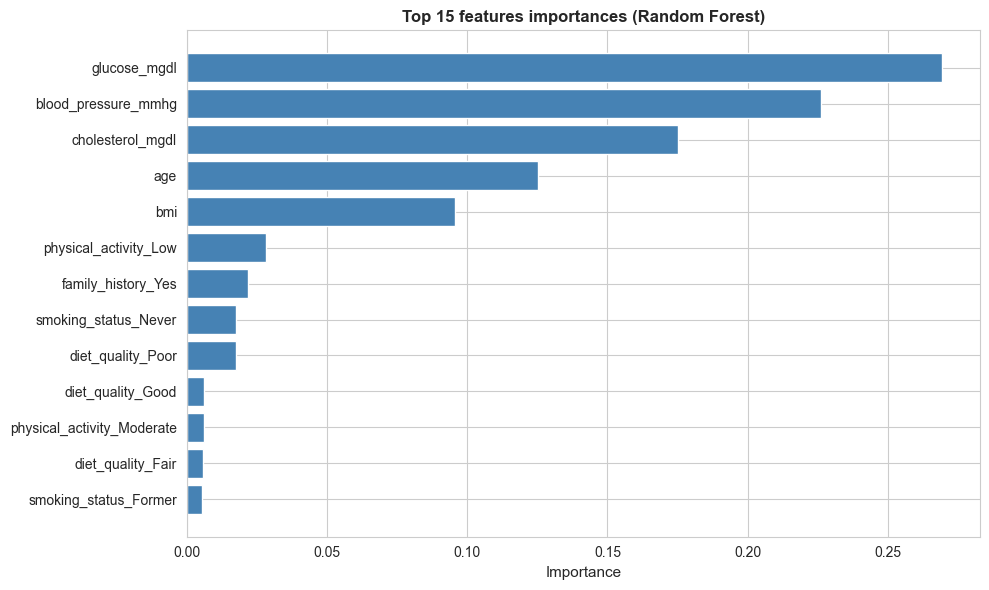

Top 10 features importances (Random Forest) :
                  feature  importance
3            glucose_mgdl    0.269330
1     blood_pressure_mmhg    0.226188
2        cholesterol_mgdl    0.175273
0                     age    0.125146
4                     bmi    0.095693
7   physical_activity_Low    0.028283
9      family_history_Yes    0.021882
6    smoking_status_Never    0.017644
12      diet_quality_Poor    0.017490
11      diet_quality_Good    0.006161


In [930]:
# Importance des features (Random Forest)
feature_importance_rf = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
plt.barh(range(len(feature_importance_rf)), feature_importance_rf['importance'].values, color='steelblue')
plt.yticks(range(len(feature_importance_rf)), feature_importance_rf['feature'].values)
plt.xlabel('Importance', fontsize=11)
plt.title('Top 15 features importances (Random Forest)', fontsize=12, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("Top 10 features importances (Random Forest) :")
print(feature_importance_rf.head(10))

In [931]:
# Modèle 3 : Decision Tree
print("\n" + "=" * 60)
print("Modèle 3 : Decision Tree")
print("=" * 60)

# Choix des variables :
depths = range(1, 21)
acc_train_split = []
acc_test_split  = []
for d in depths:
    tree = DecisionTreeClassifier(max_depth=d, criterion='gini', random_state=SEED)
    tree.fit(X_train, y_train)
    acc_train_split.append(tree.score(X_train, y_train))
    acc_test_split.append(tree.score(X_test, y_test))
    pass
best_depth_split = int(depths[np.argmax(acc_test_split)])
print(f"Meilleure profondeur (split simple) : {best_depth_split}")

leaf_sizes = range(1, 51)
acc_leaf = []
for msl in leaf_sizes:
    tree = DecisionTreeClassifier(
        max_depth=best_depth_split,
        min_samples_leaf=msl,
        criterion='gini',
        random_state=SEED
    )
    tree.fit(X_train, y_train)
    acc_leaf.append(tree.score(X_test, y_test))
    pass
best_msl = int(leaf_sizes[np.argmax(acc_leaf)])
print(f"Meilleur min_samples_leaf : {best_msl}")

dt_model = DecisionTreeClassifier(
    max_depth=best_depth_split,
    min_samples_leaf=best_msl,
    criterion='gini',
    random_state=SEED
)

dt_model.fit(X_train, y_train)

# Prédictions
y_pred_dt = dt_model.predict(X_test)
y_pred_proba_dt = dt_model.predict_proba(X_test)[:, 1]

roc_auc_dt = roc_auc_score(y_test, y_pred_proba_dt)

# Évaluation
print(f"\nAccuracy : {dt_model.score(X_test, y_test):.4f}")
print(f"ROC-AUC : {roc_auc_dt:.4f}")
print("\nRapport de classification :")
print(classification_report(y_test, y_pred_dt, target_names=['Pas de maladie', 'Maladie']))


Modèle 3 : Decision Tree
Meilleure profondeur (split simple) : 7
Meilleur min_samples_leaf : 2

Accuracy : 0.9062
ROC-AUC : 0.8460

Rapport de classification :
                precision    recall  f1-score   support

Pas de maladie       0.92      0.96      0.94       123
       Maladie       0.84      0.73      0.78        37

      accuracy                           0.91       160
     macro avg       0.88      0.84      0.86       160
  weighted avg       0.90      0.91      0.90       160



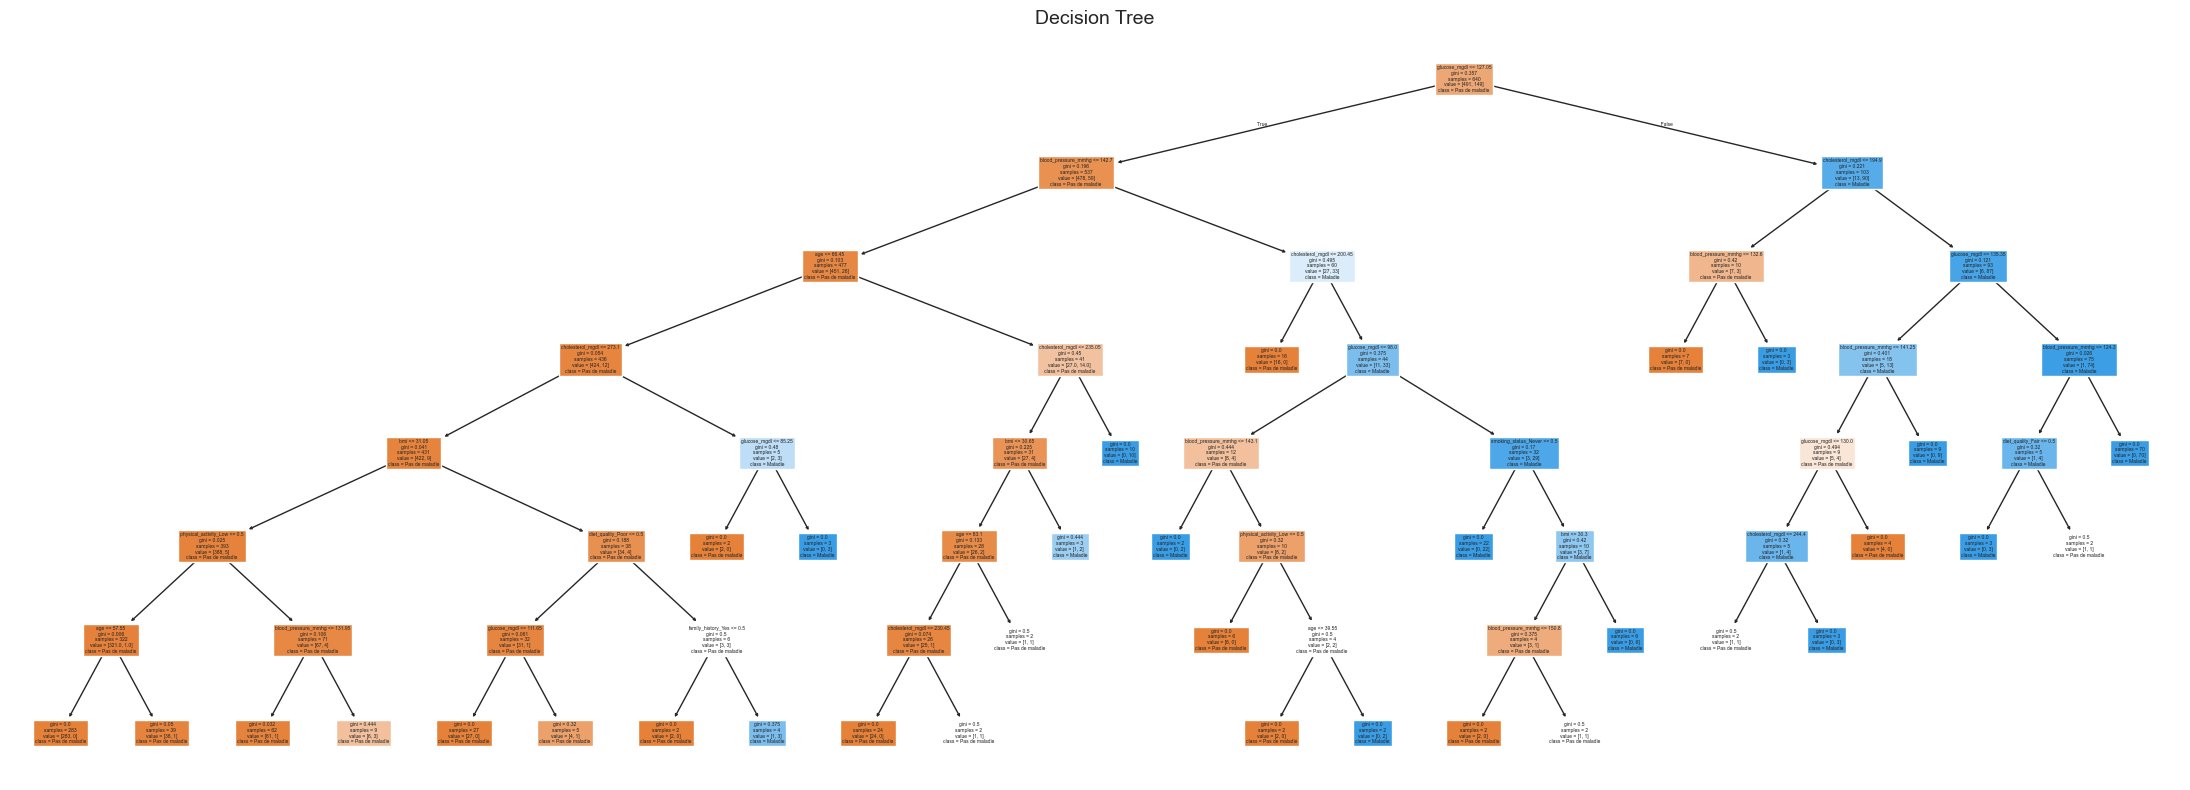

In [932]:
fig, ax = plt.subplots(figsize=(22, 8))
tree = plot_tree(dt_model, feature_names=X.columns, class_names=['Pas de maladie', 'Maladie'], filled=True, ax=ax)
plt.title("Decision Tree", fontsize=14)
plt.tight_layout()
plt.show()

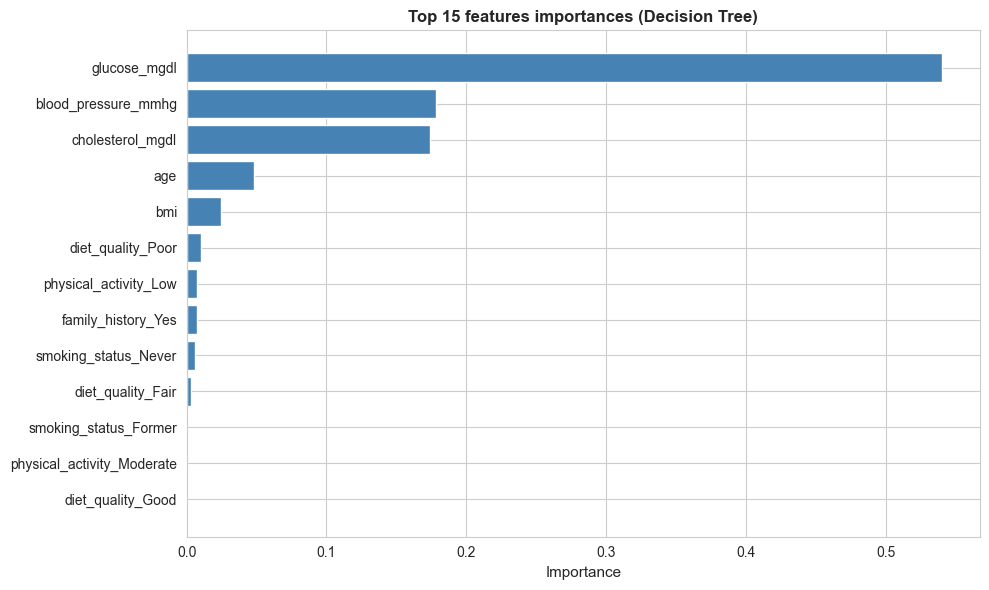

Top 10 features importances (Decision Tree) :
                  feature  importance
3            glucose_mgdl    0.540580
1     blood_pressure_mmhg    0.178612
2        cholesterol_mgdl    0.174194
0                     age    0.048390
4                     bmi    0.024677
12      diet_quality_Poor    0.010510
7   physical_activity_Low    0.007240
9      family_history_Yes    0.007100
6    smoking_status_Never    0.005857
10      diet_quality_Fair    0.002840


In [933]:
# Importance des features (Decision Tree)
feature_importance_dt = pd.DataFrame({
    'feature': X.columns,
    'importance': dt_model.feature_importances_
}).sort_values('importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
plt.barh(range(len(feature_importance_dt)), feature_importance_dt['importance'].values, color='steelblue')
plt.yticks(range(len(feature_importance_dt)), feature_importance_dt['feature'].values)
plt.xlabel('Importance', fontsize=11)
plt.title('Top 15 features importances (Decision Tree)', fontsize=12, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("Top 10 features importances (Decision Tree) :")
print(feature_importance_dt.head(10))

In [934]:
# Modèle 4 : SVM
print("\n" + "=" * 60)
print("Modèle 4 : SVM")
print("=" * 60)

svm_model = SVC(kernel='rbf', C=1.0, probability=True, random_state=SEED)
svm_model.fit(X_train_scaled, y_train)

# Prédictions
y_pred_svm = svm_model.predict(X_test_scaled)
y_pred_proba_svm = svm_model.predict_proba(X_test_scaled)[:, 1]

roc_auc_svm = roc_auc_score(y_test, y_pred_proba_svm)

# Évaluation
print(f"\nAccuracy : {svm_model.score(X_test_scaled, y_test):.4f}")
print(f"ROC-AUC : {roc_auc_svm:.4f}")
print("\nRapport de classification :")
print(classification_report(y_test, y_pred_svm, target_names=['Pas de maladie', 'Maladie']))


Modèle 4 : SVM

Accuracy : 0.9437
ROC-AUC : 0.9725

Rapport de classification :
                precision    recall  f1-score   support

Pas de maladie       0.97      0.96      0.96       123
       Maladie       0.87      0.89      0.88        37

      accuracy                           0.94       160
     macro avg       0.92      0.93      0.92       160
  weighted avg       0.94      0.94      0.94       160



## 5. Evaluation et comparaison des modèles

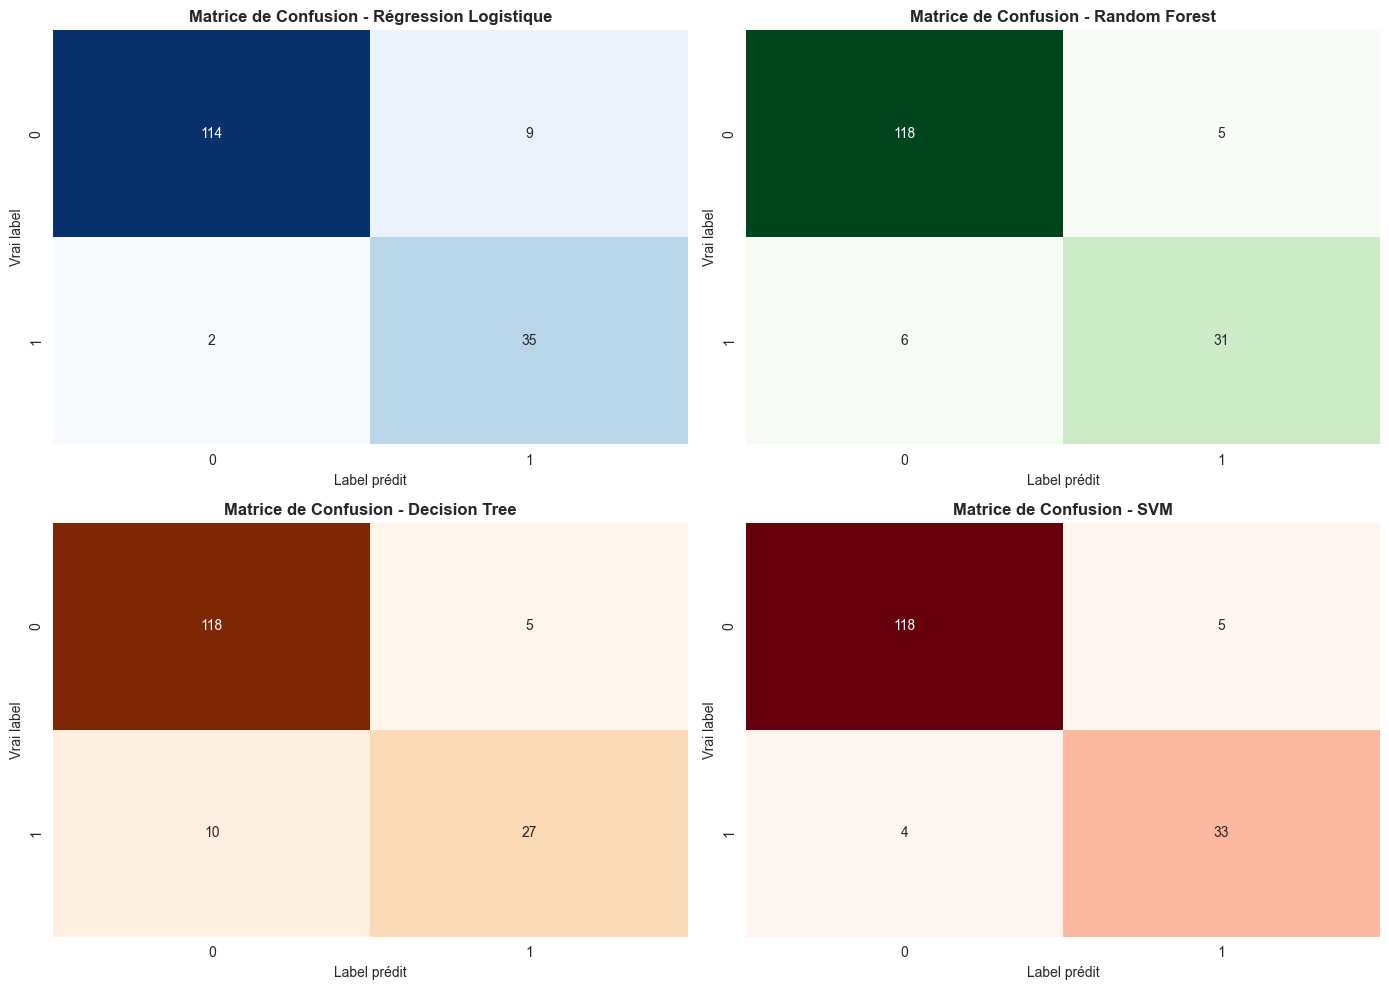

In [935]:
# Matrices de confusion
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
y_label = 'Vrai label'
x_label = 'Label prédit'

# Régression Logistique
cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False)
axes[0].set_title('Matrice de Confusion - Régression Logistique', fontweight='bold')
axes[0].set_ylabel(y_label)
axes[0].set_xlabel(x_label)

# Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', ax=axes[1], cbar=False)
axes[1].set_title('Matrice de Confusion - Random Forest', fontweight='bold')
axes[1].set_ylabel(y_label)
axes[1].set_xlabel(x_label)

# Decision Tree
cm_dt = confusion_matrix(y_test, y_pred_dt)
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Oranges', ax=axes[2], cbar=False)
axes[2].set_title('Matrice de Confusion - Decision Tree', fontweight='bold')
axes[2].set_ylabel(y_label)
axes[2].set_xlabel(x_label)

# SVM
cm_svm = confusion_matrix(y_test, y_pred_svm)
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Reds', ax=axes[3], cbar=False)
axes[3].set_title('Matrice de Confusion - SVM', fontweight='bold')
axes[3].set_ylabel(y_label)
axes[3].set_xlabel(x_label)

plt.tight_layout()
plt.show()

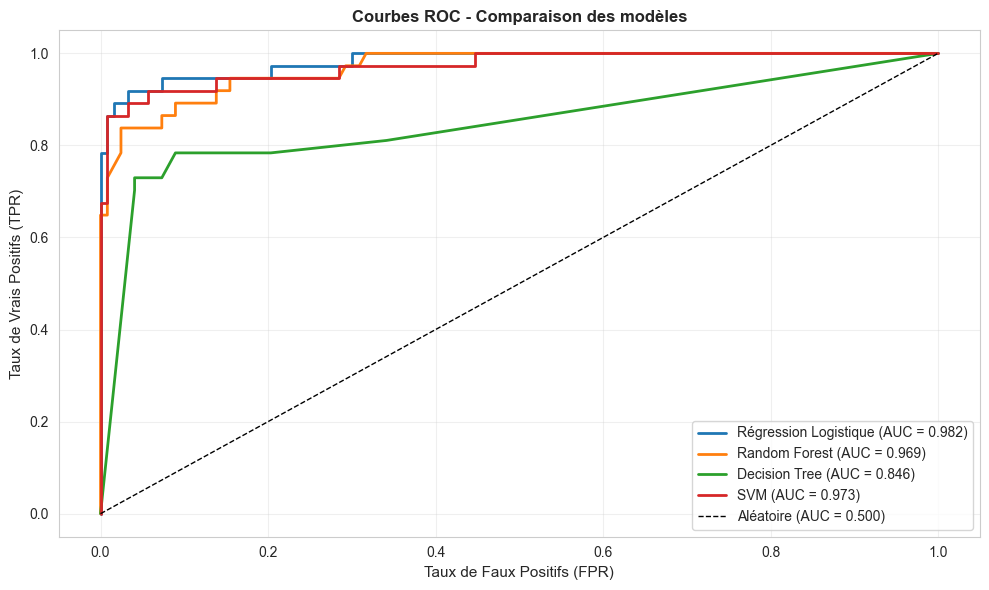

In [936]:
# Courbes ROC
plt.figure(figsize=(10, 6))

# Régression Logistique
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_pred_proba_lr)
plt.plot(fpr_lr, tpr_lr, label=f'Régression Logistique (AUC = {roc_auc_lr:.3f})', linewidth=2)

# Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_proba_rf)
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_rf:.3f})', linewidth=2)

# Decision Tree
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_pred_proba_dt)
plt.plot(fpr_dt, tpr_dt, label=f'Decision Tree (AUC = {roc_auc_dt:.3f})', linewidth=2)

# SVM
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_pred_proba_svm)
plt.plot(fpr_svm, tpr_svm, label=f'SVM (AUC = {roc_auc_svm:.3f})', linewidth=2)

# Ligne diagonale (classifier aléatoire)
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Aléatoire (AUC = 0.500)')

plt.xlabel('Taux de Faux Positifs (FPR)', fontsize=11)
plt.ylabel('Taux de Vrais Positifs (TPR)', fontsize=11)
plt.title('Courbes ROC - Comparaison des modèles', fontsize=12, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [937]:
# Comparaison résumée des modèles
from sklearn.metrics import precision_score, recall_score, f1_score

comparison_data = {
    'Métrique': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'],
    'Régression Logistique': [
        lr_model.score(X_test_scaled, y_test),
        precision_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_lr),
        roc_auc_lr
    ],
    'Random Forest': [
        rf_model.score(X_test, y_test),
        precision_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_rf),
        roc_auc_rf
    ],
    'Decision Tree': [
        dt_model.score(X_test, y_test),
        precision_score(y_test, y_pred_dt),
        recall_score(y_test, y_pred_dt),
        f1_score(y_test, y_pred_dt),
        roc_auc_dt
    ],
    'SVM': [
        svm_model.score(X_test_scaled, y_test),
        precision_score(y_test, y_pred_svm),
        recall_score(y_test, y_pred_svm),
        f1_score(y_test, y_pred_svm),
        roc_auc_svm
    ]
}

comparison_df = pd.DataFrame(comparison_data)
print("\n" + "=" * 60)
print("COMPARAISON DES MODÈLES")
print("=" * 60)
print(comparison_df.to_string(index=False))
print("=" * 60)


COMPARAISON DES MODÈLES
 Métrique  Régression Logistique  Random Forest  Decision Tree      SVM
 Accuracy               0.931250       0.931250       0.906250 0.943750
Precision               0.795455       0.861111       0.843750 0.868421
   Recall               0.945946       0.837838       0.729730 0.891892
 F1-Score               0.864198       0.849315       0.782609 0.880000
  ROC-AUC               0.982421       0.968578       0.845968 0.972534


## 6. Validation Croisée

In [938]:
# Validation croisée 5-fold
print("Validation croisée (5-Fold)\n")

# Régression Logistique
cv_scores_lr = cross_val_score(LogisticRegression(max_iter=1000, random_state=SEED), 
                                X_train_scaled, y_train, cv=5, scoring='roc_auc')
print("Régression Logistique")
print(f"ROC-AUC Scores : {cv_scores_lr}")
print(f"Moyenne : {cv_scores_lr.mean():.4f}")
print(f"Ecart-Type : {cv_scores_lr.std():.4f}\n")

# Random Forest
cv_scores_rf = cross_val_score(RandomForestClassifier(n_estimators=300, random_state=SEED, n_jobs=-1), 
                                X_train, y_train, cv=5, scoring='roc_auc')
print("Random Forest")
print(f"ROC-AUC Scores : {cv_scores_rf}")
print(f"Moyenne : {cv_scores_rf.mean():.4f}")
print(f"Ecart-Type : {cv_scores_rf.std():.4f}\n")

# Decision Tree
cv_scores_dt = cross_val_score(DecisionTreeClassifier(max_depth=best_depth_split, min_samples_leaf=best_msl, 
                                                       criterion='gini', random_state=SEED), 
                                X_train, y_train, cv=5, scoring='roc_auc')
print("Decision Tree")
print(f"ROC-AUC Scores : {cv_scores_dt}")
print(f"Moyenne : {cv_scores_dt.mean():.4f}")
print(f"Ecart-Type : {cv_scores_dt.std():.4f}\n")

# SVM
cv_scores_svm = cross_val_score(SVC(kernel='rbf', C=1.0, probability=True, random_state=SEED), 
                                 X_train_scaled, y_train, cv=5, scoring='roc_auc')
print("SVM")
print(f"ROC-AUC Scores : {cv_scores_svm}")
print(f"Moyenne : {cv_scores_svm.mean():.4f}")
print(f"Ecart-Type : {cv_scores_svm.std():.4f}")

Validation croisée (5-Fold)

Régression Logistique
ROC-AUC Scores : [0.99164054 0.99353741 0.99319728 0.99591837 0.98265306]
Moyenne : 0.9914
Ecart-Type : 0.0046

Random Forest
ROC-AUC Scores : [0.9707419  0.99285714 0.98911565 0.99336735 0.9702381 ]
Moyenne : 0.9833
Ecart-Type : 0.0105

Decision Tree
ROC-AUC Scores : [0.92250087 0.85816327 0.9335034  0.9047619  0.84914966]
Moyenne : 0.8936
Ecart-Type : 0.0340

SVM
ROC-AUC Scores : [0.97910136 0.9877551  0.98979592 0.9962585  0.97687075]
Moyenne : 0.9860
Ecart-Type : 0.0071


## 7. Analyse des performances

### 7.1 Équilibre des classes et implications

In [939]:
# Analyse de l'équilibre des classes
print("=" * 60)
print("ÉQUILIBRE DES CLASSES")
print("=" * 60)

# Distribution dans l'ensemble complet
print("\nDistribution complète :")
print(f"  Classe 0 (Pas de maladie): {(y == 0).sum()} ({(y == 0).mean()*100:.1f}%)")
print(f"  Classe 1 (Maladie):        {(y == 1).sum()} ({(y == 1).mean()*100:.1f}%)")
print(f"  Ratio: {(y == 1).sum() / (y == 0).sum():.2f}")

# Distribution en train
print("\nDistribution train (80%) :")
print(f"  Classe 0: {(y_train == 0).sum()} ({(y_train == 0).mean()*100:.1f}%)")
print(f"  Classe 1: {(y_train == 1).sum()} ({(y_train == 1).mean()*100:.1f}%)")

# Distribution en test
print("\nDistribution test (20%) :")
print(f"  Classe 0: {(y_test == 0).sum()} ({(y_test == 0).mean()*100:.1f}%)")
print(f"  Classe 1: {(y_test == 1).sum()} ({(y_test == 1).mean()*100:.1f}%)")


ÉQUILIBRE DES CLASSES

Distribution complète :
  Classe 0 (Pas de maladie): 614 (76.8%)
  Classe 1 (Maladie):        186 (23.2%)
  Ratio: 0.30

Distribution train (80%) :
  Classe 0: 491 (76.7%)
  Classe 1: 149 (23.3%)

Distribution test (20%) :
  Classe 0: 123 (76.9%)
  Classe 1: 37 (23.1%)


#### Interprétation

Le dataset est légèrement déséquilibré (ratio de 0.30)

Attention requise en interprétant l'`accuracy`

Privilégier `f1-score`, `recall`, `precision`.

### 7.2 Sensibilité vs Spécificité

En contexte médical, **Sensibilité** et **Spécificité** sont les métriques fondamentales :

- **Sensibilité**
  - Capacité à détecter les malades
  - Un faux négatif peut être dangereux (maladie non traitée)
  
- **Spécificité**
  - Capacité à confirmer l'absence de maladie
  - Un faux positif peut entraîner des traitements inutiles


SENSIBILITÉ vs SPÉCIFICITÉ
               Modèle  Sensibilité (%)  Spécificité (%) Équilibre
Régression Logistique        94.594595        92.682927      1.9%
        Random Forest        83.783784        95.934959     12.2%
        Decision Tree        72.972973        95.934959     23.0%
                  SVM        89.189189        95.934959      6.7%


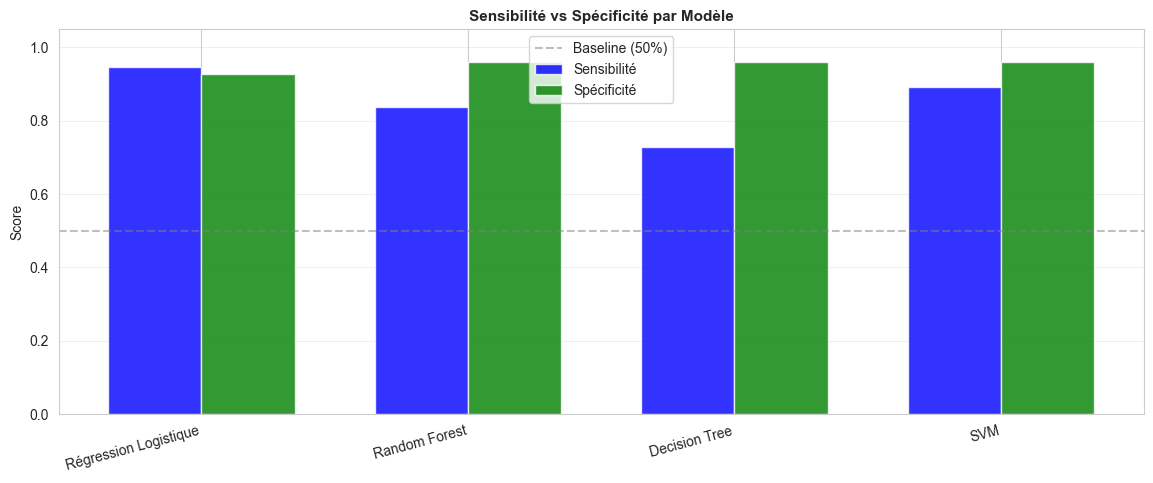

In [940]:
# Extraction des composants des matrices de confusion pour tous les modèles
def extract_cm_components(cm):
    tn, fp, fn, tp = cm.ravel()
    return {'TN': tn, 'FP': fp, 'FN': fn, 'TP': tp}

cm_dict = {
    'Régression Logistique': extract_cm_components(cm_lr),
    'Random Forest': extract_cm_components(cm_rf),
    'Decision Tree': extract_cm_components(cm_dt),
    'SVM': extract_cm_components(cm_svm)
}

# Calcul de Sensibilité et Spécificité pour chaque modèle
def calc_sensitivity_specificity(cm):
    """Calcule sensibilité et spécificité à partir d'une matrice de confusion"""
    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    return sensitivity, specificity

# Calculs
sens_lr, spec_lr = calc_sensitivity_specificity(cm_lr)
sens_rf, spec_rf = calc_sensitivity_specificity(cm_rf)
sens_dt, spec_dt = calc_sensitivity_specificity(cm_dt)
sens_svm, spec_svm = calc_sensitivity_specificity(cm_svm)


# Graphique : Sensibilité vs Spécificité
fig, axes = plt.subplots(1, 1, figsize=(14, 5))
modeles = list(cm_dict.keys())

sensitivities = [sens_lr, sens_rf, sens_dt, sens_svm]
specificities = [spec_lr, spec_rf, spec_dt, spec_svm]

x = np.arange(len(modeles))
width = 0.35

axes.bar(x - width/2, sensitivities, width, label='Sensibilité', color='Blue', alpha=0.8)
axes.bar(x + width/2, specificities, width, label='Spécificité', color='Green', alpha=0.8)

axes.set_ylabel('Score')
axes.set_title('Sensibilité vs Spécificité par Modèle', fontweight='bold', fontsize=11)
axes.set_xticks(x)
axes.set_xticklabels(modeles, rotation=15, ha='right')
axes.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Baseline (50%)')
axes.legend()
axes.set_ylim([0, 1.05])
axes.grid(axis='y', alpha=0.3)

print("\n" + "=" * 60)
print("SENSIBILITÉ vs SPÉCIFICITÉ")
print("=" * 60)

clinical_metrics = pd.DataFrame({
    'Modèle': ['Régression Logistique', 'Random Forest', 'Decision Tree', 'SVM'],
    'Sensibilité (%)': [sens_lr*100, sens_rf*100, sens_dt*100, sens_svm*100],
    'Spécificité (%)': [spec_lr*100, spec_rf*100, spec_dt*100, spec_svm*100],
    'Équilibre': [
        f"{abs(sens_lr - spec_lr)*100:.1f}%",
        f"{abs(sens_rf - spec_rf)*100:.1f}%",
        f"{abs(sens_dt - spec_dt)*100:.1f}%",
        f"{abs(sens_svm - spec_svm)*100:.1f}%"
    ]
})

print(clinical_metrics.to_string(index=False))

#### Interprétation

1. **Régression Logistique**
    - Détecte 94.6% des malades (sensibilité)
    - Confirme 92.7% des personnes saines (spécificité)
    - Ecart de 1.9% -> équilibré (bon compromis)

2. **Random Forest**
    - Détecte 83.8% des malades (sensibilité)
    - Confirme 95.9% des personnes saines (spécificité)
    - Ecart de 12.2% -> favorise la confirmation (risque de faux négatifs élevé)

3. **Decision Tree**
    - Détecte 73.0% des malades (sensibilité)
    - Confirme 95.9% des personnes saines (spécificité)
    - Ecart de 23.0% -> favorise la confirmation (risque de faux négatifs très élevé)

4. **SVM**
    - Détecte 89.2% des malades (sensibilité)
    - Confirme 95.9% des personnes saines (spécificité)
    - Ecart : 6.7% -> équilibré (bon compromis)

### 7.3 Faux Positifs vs Faux Négatifs

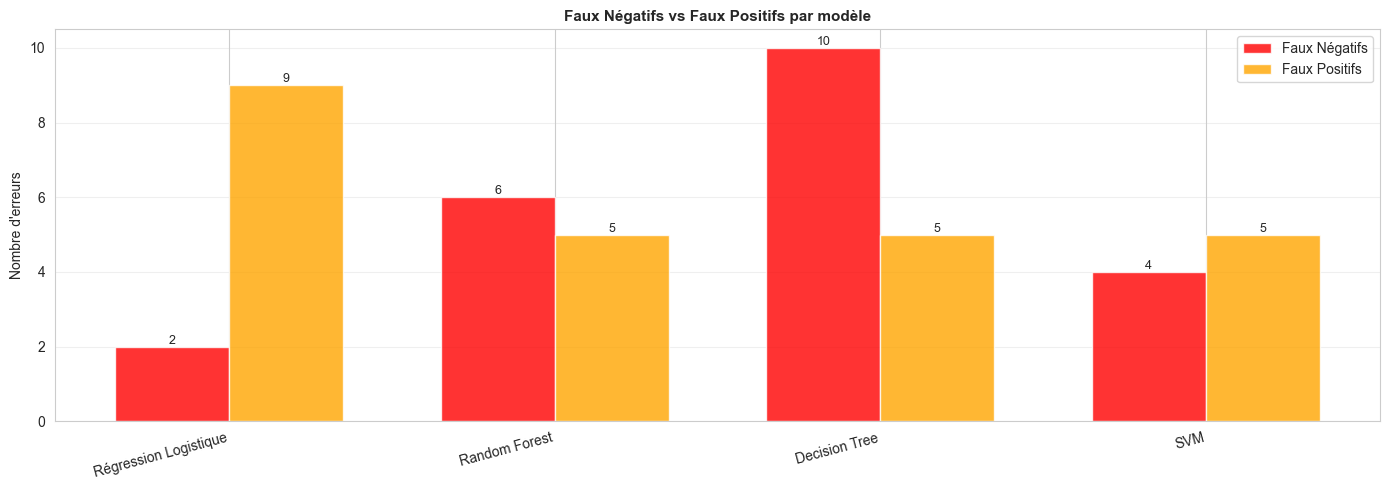


TABLEAU COMPARATIF DES ERREURS PAR MODÈLE
               Modèle  Vrai Positif  Vrai Négatif  Faux Positif  Faux Négatif
Régression Logistique            35           114             9             2
        Random Forest            31           118             5             6
        Decision Tree            27           118             5            10
                  SVM            33           118             5             4


In [941]:
# Graphique : Comparaison des erreurs (FN vs FP)
fig, axes = plt.subplots(1, 1, figsize=(14, 5))

fn_counts = [cm_dict[m]['FN'] for m in modeles]
fp_counts = [cm_dict[m]['FP'] for m in modeles]

x = np.arange(len(modeles))
width = 0.35

bars1 = axes.bar(x - width/2, fn_counts, width, label='Faux Négatifs', color='Red', alpha=0.8)
bars2 = axes.bar(x + width/2, fp_counts, width, label='Faux Positifs', color='Orange', alpha=0.8)

axes.set_ylabel('Nombre d\'erreurs')
axes.set_title('Faux Négatifs vs Faux Positifs par modèle', fontweight='bold', fontsize=11)
axes.set_xticks(x)
axes.set_xticklabels(modeles, rotation=15, ha='right')
axes.legend()
axes.grid(axis='y', alpha=0.3)

# Ajouter les valeurs sur les barres
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        axes.text(bar.get_x() + bar.get_width()/2., height,
                    f'{int(height)}',
                    ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# Tableau comparatif des erreurs
print("\n" + "=" * 60)
print("TABLEAU COMPARATIF DES ERREURS PAR MODÈLE")
print("=" * 60)

error_comparison = pd.DataFrame({
    'Modèle': list(cm_dict.keys()),
    'Vrai Positif': [cm_dict[m]['TP'] for m in cm_dict],
    'Vrai Négatif': [cm_dict[m]['TN'] for m in cm_dict],
    'Faux Positif': [cm_dict[m]['FP'] for m in cm_dict],
    'Faux Négatif': [cm_dict[m]['FN'] for m in cm_dict]
})

print(error_comparison.to_string(index=False))


#### Observations

- **Meilleure détection des malades** (sensibilité) : Régression Logistique (94.6%)
- **Meilleure confirmation des personnes saines** (spécificité) : Random Forest, Decision Tree, SVM (95.9%)
- **Moins de faux négatifs** : Régression Logistique (2 erreurs)
- **Moins de faux positifs** : Random Forest, Decision Tree, SVM (5 erreurs)

## 8. Conclusions et recommandations finales

### 8.1 Résumé analytique de l'étude

#### 8.1.1 Données

- 800 patients, 13 features, 1 target
- Classes : 614 personnes saines (0), 186 malades (1)
- Ratio : 0.30 (dataset bien équilibré)

#### 8.1.2 Modèles entraînés

1. **Régression Logistique**
    - ROC-AUC = 0.982
    - Sensibilité = 94.6%
    - Spécificité = 92.7%

2. **Decision Tree**
    - ROC-AUC = 0.846
    - Sensibilité = 73.0%
    - Spécificité = 95.9%

3. **Random Forest**
    - ROC-AUC = 0.969
    - Sensibilité = 83.8%
    - Spécificité = 95.9%

4. **SVM**
    - ROC-AUC = 0.973
    - Sensibilité = 89.2%
    - Spécificité = 95.9%

### 8.2 Pourquoi la régression logistique est le meilleur modèle

#### 8.2.1 Performances supérieures

La régression logistique obtient le **meilleur ROC-AUC** de tous les modèles testés avec un score de **0.982**, surpassant :
- **SVM** : 0.973
- **Random Forest** : 0.969
- **Decision Tree** : 0.846

#### 8.2.2 Contexte clinique optimal

Pour un problème de **dépistage de maladies**, la sensibilité est cruciale car il est primordial de détecter les vrais malades. La régression logistique excelle sur ce critère :
- **Sensibilité : 94.6%** : détecte 94.6% des patients malades
- **Spécificité : 92.7%** : bon équilibre, évite un excès de faux positifs

Ce modèle offre le meilleur compromis pour minimiser les **faux négatifs** (patients malades non détectés).

#### 8.2.3 Avantages pratiques

1. **Simplicité et interprétabilité** : En médecine, pouvoir expliquer les prédictions est essentiel. La régression logistique offre des coefficients directement interprétables.

2. **Robustesse** : Malgré sa simplicité, elle surpasse des modèles plus complexes comme Random Forest et SVM.

3. **Dataset adapté** : Avec 800 patients et un dataset bien équilibré (ratio 0.30), la régression logistique dispose de suffisamment de données sans nécessiter la complexité de méthodes d'ensemble.

4. **Pas de surapprentissage** : Contrairement au Decision Tree (AUC 0.846), la régression logistique généralise mieux sur les données de test.

#### 8.2.4 Conclusion

La régression logistique combine **performance maximale** (0.982 AUC), **excellente sensibilité clinique** (94.6%), et **simplicité d'implémentation/interprétation**. Elle représente le choix optimal pour ce problème de prédiction de pathologie.

### 8.3 Limitations de l'approche et perspectives d'amélioration

#### 8.3.1 Limitations identifiées

1. **Taille limitée du dataset**
   - Seulement 800 patients, dont 186 malades (23.25%)
   - Pour une application médicale critique, un dataset plus large (plusieurs milliers de patients) améliorerait la robustesse des modèles
   - Risque de ne pas capturer toute la diversité des profils de patients

2. **Nature synthétique des données**
   - Les données SynMedTab-800 sont générées synthétiquement
   - Elles peuvent ne pas refléter parfaitement la complexité des données cliniques réelles

3. **Traitement des valeurs manquantes**
   - Imputation par la moyenne/mode : approche simple mais pouvant introduire des biais
   - Des méthodes plus sophistiquées pourraient être explorées
   - Jusqu'à 12.5% de valeurs manquantes dans certaines variables

4. **Absence d'optimisation des hyperparamètres**
   - Les modèles ont été entraînés avec leurs paramètres par défaut
   - Une recherche systématique aurait pu améliorer les performances

#### 8.3.2 Ce qui aurait été fait différemment avec plus de temps/données

**Avec plus de temps :**

1. **Feature engineering approfondi**
   - Analyse des interactions entre variables (ex: tabagisme × pression artérielle)

2. **Analyse d'explicabilité**
   - Courbes d'influence pour identifier les seuils critiques
   - Analyse des cas mal classifiés pour identifier des patterns

3. **Validation plus robuste**
   - Repeated K-Fold cross-validation (plusieurs répétitions)

**Avec plus de données :**

1. **Dataset plus large**
   - Minimum 5000-10000 patients pour une application médicale robuste
   - Permettrait d'entraîner des modèles plus complexes sans surapprentissage
   - Améliorerait la confiance statistique des résultats

2. **Données réelles multi-centres**
   - Validation sur plusieurs hôpitaux/centres médicaux
   - Prise en compte de la variabilité géographique et démographique
   - Test de généralisation sur différentes populations

3. **Features supplémentaires**
   - Historique médical détaillé des patients
   - Résultats d'examens complémentaires

4. **Segmentation des patients**
   - Modèles spécialisés par sous-groupes (âge, sexe, comorbidités)
   - Approches personnalisées selon le profil de risque

> L'IA a été une aide pour la rédaction de ce rapport, et une aide technique pour la production du code.